# Classification Project

## Diabetes Prediction using Machine Learning

### Module
Concepts and Technologies of Artificial Intelligence (5CS037)

### Student
Your Name

### Dataset
Diabetes Dataset

### Objective
To predict whether a patient has diabetes using machine learning classification algorithms.

In [19]:
# ==========================================================
# IMPORTING REQUIRED LIBRARIES
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

print("All libraries imported successfully!")

All libraries imported successfully!


# Upload Dataset

Upload the diabetes dataset manually before loading it into the notebook.

In [20]:
# ==========================================================
# MANUAL DATASET UPLOAD (Google Colab)
# ==========================================================

from google.colab import files

uploaded = files.upload()

Saving diabetes_dataset.csv to diabetes_dataset (1).csv


In [21]:
# Check uploaded files

import os

print(os.listdir())

['.config', 'diabetes_dataset.csv', 'diabetes_dataset (1).csv', 'sample_data']


In [22]:
# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("diabetes_dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [23]:
# Display First Five Rows

df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [24]:
# Display Last Five Rows

df.tail()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0
99999,52,Female,White,Postgraduate,Middle,Employed,Never,1,248,2.7,...,31,183,87,91,142,15.93,5.73,27.9,Pre-Diabetes,0


# Dataset Overview

This section provides a general understanding of the dataset before preprocessing and model building.

In [25]:
# Dataset Shape

rows, columns = df.shape

print("Number of Rows :", rows)
print("Number of Columns :", columns)

Number of Rows : 100000
Number of Columns : 31


In [26]:
# Column Names

df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [27]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [28]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


In [29]:
# Data Types

df.dtypes

,0
age,int64
gender,object
ethnicity,object
education_level,object
income_level,object
employment_status,object
smoking_status,object
alcohol_consumption_per_week,int64
physical_activity_minutes_per_week,int64
diet_score,float64


In [30]:
# Missing Values

missing_values = df.isnull().sum()

missing_values

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


In [31]:
# Missing Value Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
age,0.0
gender,0.0
ethnicity,0.0
education_level,0.0
income_level,0.0
employment_status,0.0
smoking_status,0.0
alcohol_consumption_per_week,0.0
physical_activity_minutes_per_week,0.0
diet_score,0.0


In [32]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [33]:
# Remove Duplicate Records

df = df.drop_duplicates()

print("Remaining Records :", len(df))

Remaining Records : 100000


In [34]:
# Unique Values

df.nunique()

,0
age,73
gender,3
ethnicity,5
education_level,4
income_level,5
employment_status,4
smoking_status,3
alcohol_consumption_per_week,11
physical_activity_minutes_per_week,620
diet_score,101


In [35]:
# Complete Summary

df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,50.12041,15.6046,18.0,39.0,50.0,61.0,90.0
gender,100000,3,Female,50216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,100000,5,White,44997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,100000,4,Highschool,44891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_level,100000,5,Middle,35152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,60175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,100000,3,Never,59813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol_consumption_per_week,100000.0,NaN,NaN,NaN,2.00367,1.417779,0.0,1.0,2.0,3.0,10.0
physical_activity_minutes_per_week,100000.0,NaN,NaN,NaN,118.91164,84.409662,0.0,57.0,100.0,160.0,833.0
diet_score,100000.0,NaN,NaN,NaN,5.994787,1.780954,0.0,4.8,6.0,7.2,10.0


In [36]:
# Separate Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diagnosed_diabetes'],
      dtype='object')

Categorical Columns
Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'diabetes_stage'],
      dtype='object')


In [37]:
# Count Numerical Features

len(numerical_columns)

24

In [38]:
# Count Categorical Features

len(categorical_columns)

7

In [39]:
# Display Unique Values in Categorical Columns

for column in categorical_columns:

    print("="*60)
    print(column)
    print("="*60)

    print(df[column].value_counts())

    print()

gender
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

ethnicity
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

education_level
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

income_level
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

employment_status
employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

smoking_status
smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64

diabetes_stage
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64



# Data Cleaning

Before building machine learning models, the dataset is cleaned to improve data quality. This process includes checking for missing values, removing duplicate records, handling categorical variables, and preparing the dataset for analysis.

In [40]:
# ==========================================================
# CHECKING MISSING VALUES
# ==========================================================

missing_values = df.isnull().sum()

print(missing_values)

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [41]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
age,0.0
gender,0.0
ethnicity,0.0
education_level,0.0
income_level,0.0
employment_status,0.0
smoking_status,0.0
alcohol_consumption_per_week,0.0
physical_activity_minutes_per_week,0.0
diet_score,0.0


In [42]:
# Fill numerical missing values with median

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [43]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [44]:
df = df.drop_duplicates()

print("Remaining Rows:", len(df))

Remaining Rows: 100000


In [45]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'diabetes_stage'],
      dtype='object')


Label Encoding

In [46]:
encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [47]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,1,0,1,2,0,2,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,0,4,1,3,0,1,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,1,0
2,60,1,2,1,3,3,2,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,0,1,1,1,1,2,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,1,4,0,3,1,2,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,4,1


#Exploratory Data Analysis (EDA)

Visualization 1
Class Distribution

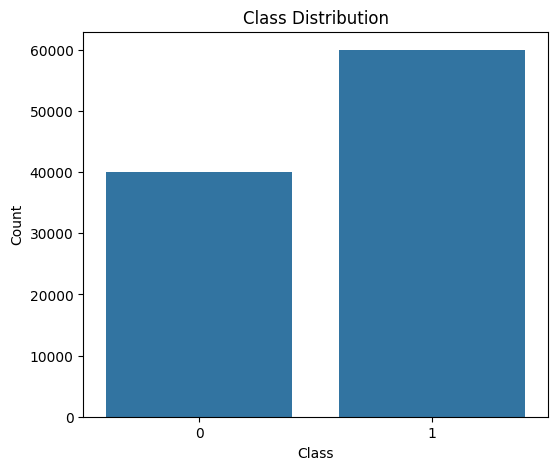

In [48]:
target_column = df.columns[-1]      # assumes target is last column

plt.figure(figsize=(6,5))

sns.countplot(x=target_column, data=df)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

Visualization 2
Correlation Heatmap

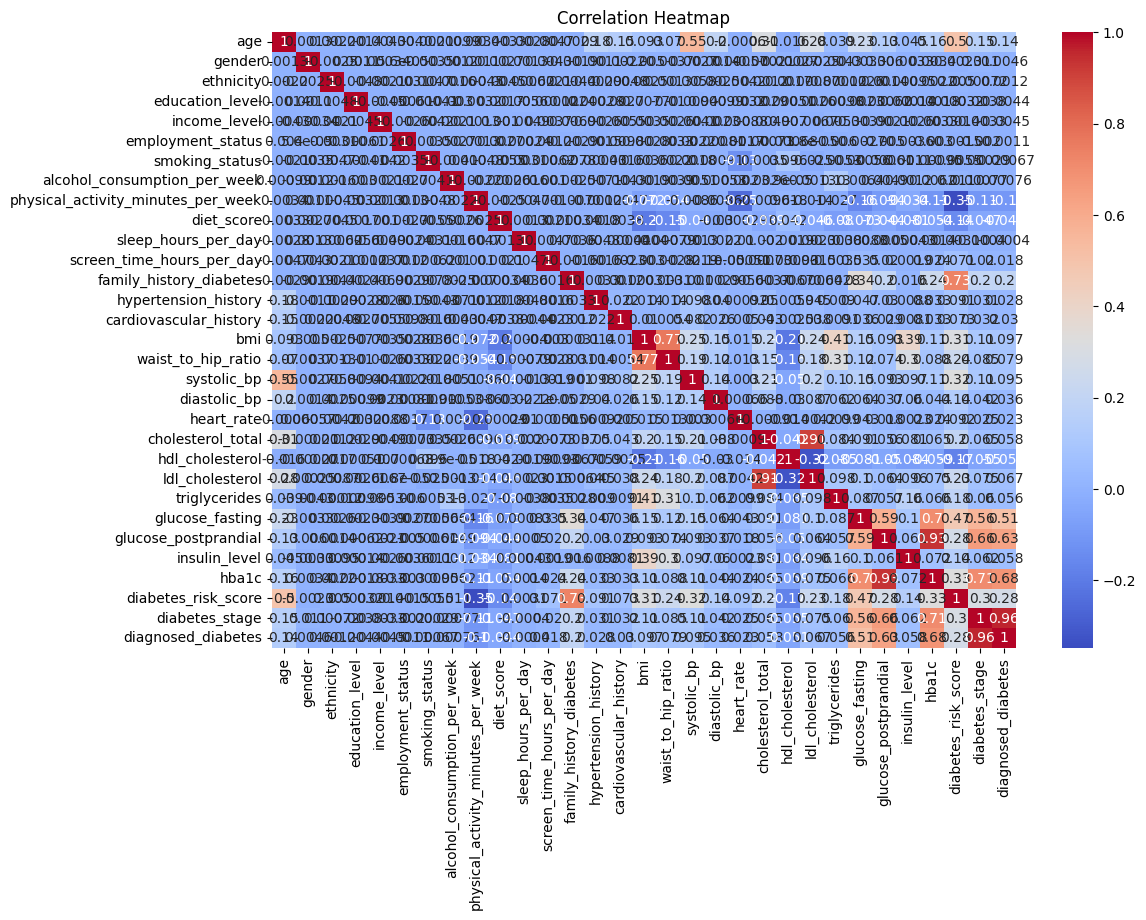

In [49]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

Visualization 3
Histograms

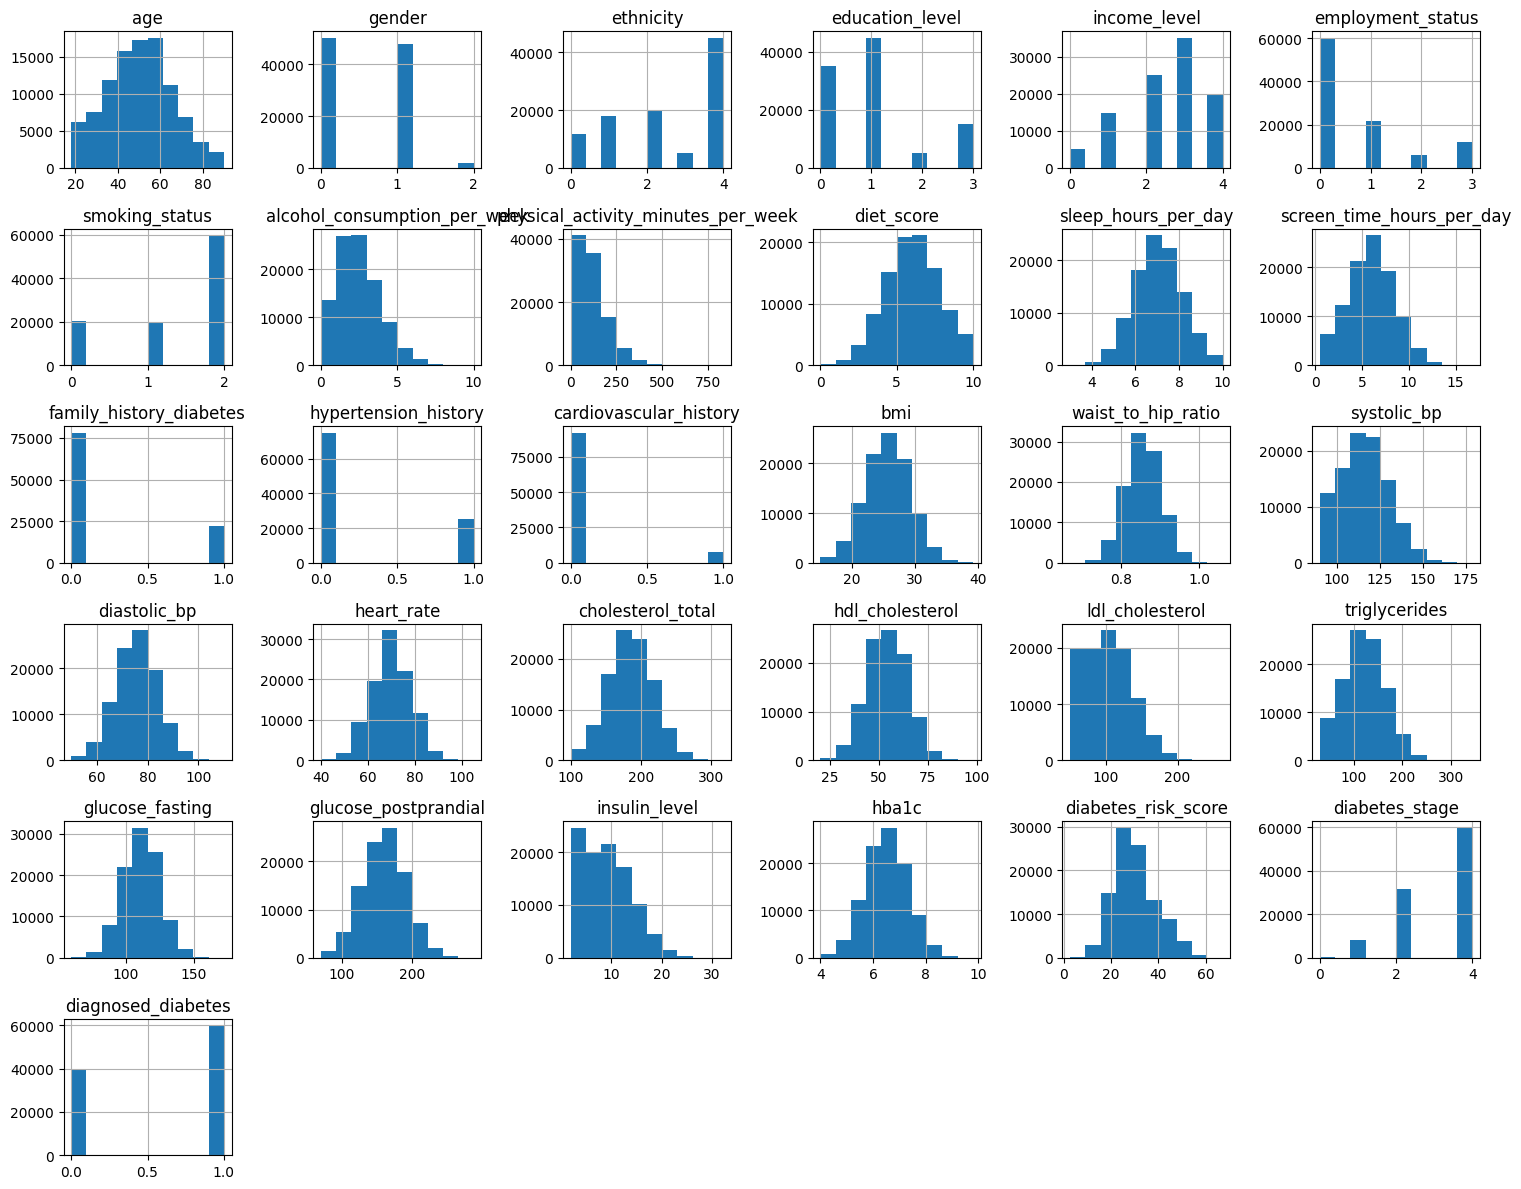

In [50]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

Visualization 4
Boxplots

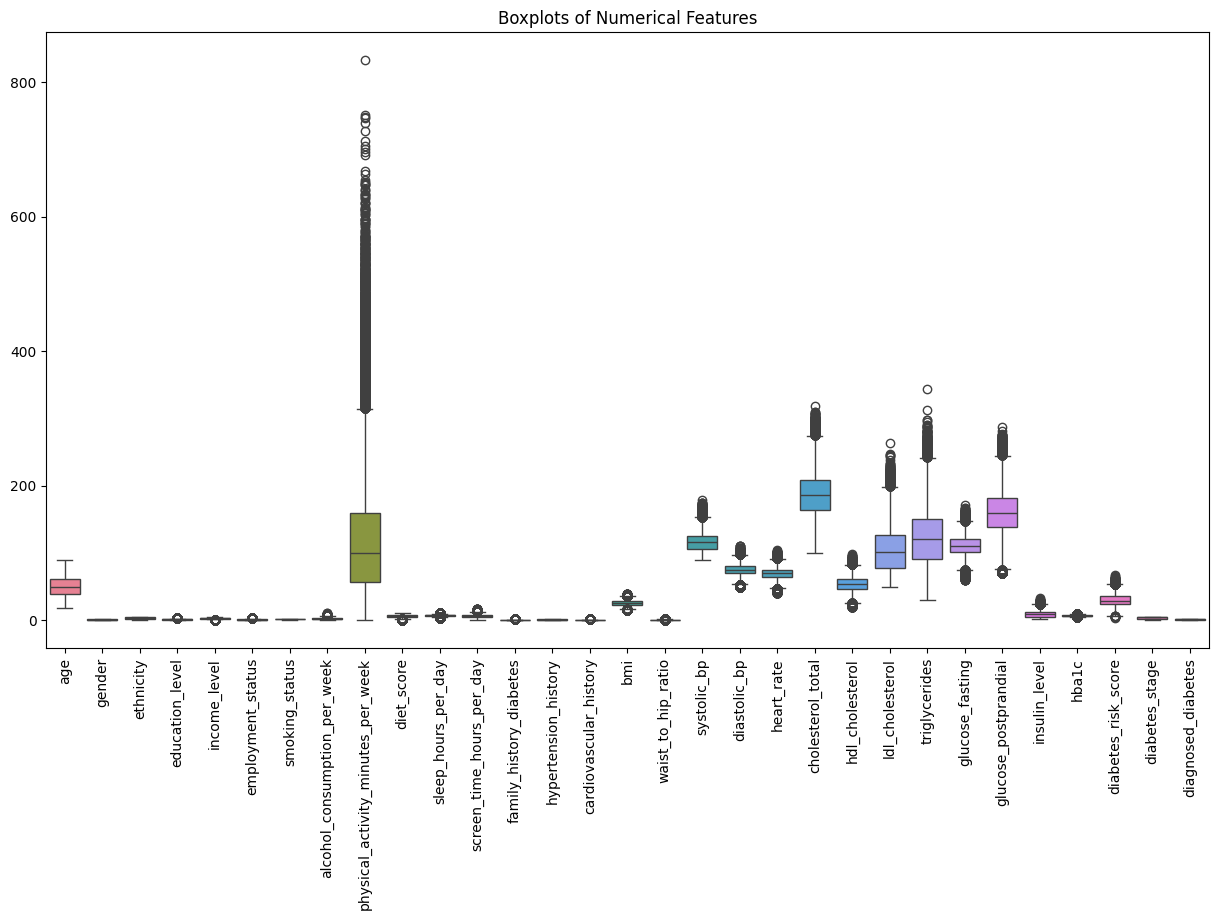

In [51]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplots of Numerical Features")

plt.show()

Visualization 5
Pair Plot

In [ ]:
sns.pairplot(df, hue=target_column)

plt.show()

Visualization 6
Feature Distribution

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns[:-1]

for col in numeric_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

Visualization 7
Class-wise Boxplot

In [ ]:
feature = numeric_cols[0]

plt.figure(figsize=(7,5))

sns.boxplot(x=target_column,
            y=feature,
            data=df)

plt.title(f"{feature} vs Class")

plt.show()

Visualization 8
Scatter Plot

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x=numeric_cols[0],
                y=numeric_cols[1],
                hue=target_column,
                data=df)

plt.title("Scatter Plot")

plt.show()

Visualization 9
Correlation with Target

In [ ]:
correlation = df.corr(numeric_only=True)[target_column].sort_values()

plt.figure(figsize=(8,6))

correlation.plot(kind="barh")

plt.title("Feature Correlation with Target")

plt.show()

Visualization 10
Missing Values Heatmap

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False)

plt.title("Missing Values Heatmap")

plt.show()


SECTION 9: Final Dataset Check

In [ ]:
print("="*60)

print("Final Dataset Shape")

print("="*60)

print(df.shape)

print()

print("Missing Values")

print(df.isnull().sum().sum())

print()

print("Duplicate Rows")

print(df.duplicated().sum())

# Data Preprocessing

Before training machine learning models, the dataset is prepared by:

- Selecting input features and target variable
- Splitting into training and testing sets
- Standardizing numerical features

In [ ]:
# ==========================================================
# SELECT FEATURES AND TARGET
# ==========================================================

target = "Outcome"       # Change if necessary

X = df.drop(columns=[target])

y = df[target]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

In [ ]:
print(y.value_counts())

In [ ]:
# ==========================================================
# SPLIT DATASET
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

In [ ]:
# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully!")

# Neural Network Classifier

The Multi-Layer Perceptron (MLPClassifier) is used for diabetes classification.

Architecture:

- One hidden layer
- 100 neurons
- ReLU activation
- Adam optimizer

In [ ]:
# ==========================================================
# BUILD MLP CLASSIFIER
# ==========================================================

mlp = MLPClassifier(

    hidden_layer_sizes=(100,),

    activation="relu",

    solver="adam",

    learning_rate="adaptive",

    max_iter=500,

    random_state=42

)

In [ ]:
mlp.fit(

    X_train_scaled,

    y_train

)

print("Neural Network Training Completed!")

In [ ]:
mlp_predictions = mlp.predict(

    X_test_scaled
)

In [ ]:
mlp_accuracy = accuracy_score(

    y_test,

    mlp_predictions

)

print("Accuracy :", mlp_accuracy)

In [ ]:
mlp_precision = precision_score(

    y_test,

    mlp_predictions
)

print("Precision :", mlp_precision)

In [ ]:
mlp_recall = recall_score(

    y_test,

    mlp_predictions
)

print("Recall :", mlp_recall)

In [ ]:
mlp_f1 = f1_score(

    y_test,

    mlp_predictions
)

print("F1 Score :", mlp_f1)

In [ ]:
print(classification_report(

    y_test,

    mlp_predictions

))

In [ ]:
cm = confusion_matrix(

    y_test,

    mlp_predictions

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [ ]:
probability = mlp.predict_proba(

    X_test_scaled

)[:,1]

fpr,tpr,threshold = roc_curve(

    y_test,

    probability

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    label="AUC = %.3f"%roc_auc

)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(

    mlp.loss_curve_

)

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.title("Neural Network Loss Curve")

plt.grid(True)

plt.show()

In [ ]:
mlp_results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        mlp_accuracy,

        mlp_precision,

        mlp_recall,

        mlp_f1

    ]

})

mlp_results

In [ ]:
prediction_table = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":mlp_predictions

})

prediction_table.head(20)

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(

    probability,

    bins=30,

    kde=True

)

plt.title("Prediction Probability Distribution")

plt.show()

# Logistic Regression

Logistic Regression is a supervised learning algorithm used for binary classification. It estimates the probability that an observation belongs to a particular class.

In [ ]:
# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully!")

In [ ]:
logistic_predictions = logistic_model.predict(X_test_scaled)

In [ ]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

logistic_precision = precision_score(y_test, logistic_predictions)

logistic_recall = recall_score(y_test, logistic_predictions)

logistic_f1 = f1_score(y_test, logistic_predictions)

print("Accuracy :", logistic_accuracy)
print("Precision :", logistic_precision)
print("Recall :", logistic_recall)
print("F1 Score :", logistic_f1)

Classification Report

In [ ]:
print(classification_report(y_test, logistic_predictions))

Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, logistic_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Random Forest Classifier

In [ ]:
random_forest = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

In [ ]:
random_forest.fit(

    X_train,

    y_train

)

print("Random Forest Model Trained Successfully!")

Prediction

In [ ]:
rf_predictions = random_forest.predict(

    X_test
)

Evaluation

In [ ]:
rf_accuracy = accuracy_score(

    y_test,

    rf_predictions

)

rf_precision = precision_score(

    y_test,

    rf_predictions

)

rf_recall = recall_score(

    y_test,

    rf_predictions

)

rf_f1 = f1_score(

    y_test,

    rf_predictions

)

print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)

Classification Report

In [ ]:
print(classification_report(

    y_test,

    rf_predictions

))

Confusion Matrix

In [ ]:
cm = confusion_matrix(

    y_test,

    rf_predictions

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

Feature Importance

In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":random_forest.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

Feature Importance Plot

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance

)

plt.title("Random Forest Feature Importance")

plt.show()

#Hyperparameter Tuning

In [ ]:
rf_parameters = {

    "n_estimators":[100,200],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

rf_grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    rf_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

rf_grid.fit(X_train,y_train)

print(rf_grid.best_params_)

print(rf_grid.best_score_)

Best Random Forest

In [ ]:
best_rf = rf_grid.best_estimator_

best_predictions = best_rf.predict(X_test)

Evaluation

In [ ]:
best_rf_accuracy = accuracy_score(

    y_test,

    best_predictions

)

best_rf_precision = precision_score(

    y_test,

    best_predictions

)

best_rf_recall = recall_score(

    y_test,

    best_predictions

)

best_rf_f1 = f1_score(

    y_test,

    best_predictions
)

print("Accuracy :",best_rf_accuracy)

print("Precision :",best_rf_precision)

print("Recall :",best_rf_recall)

print("F1 :",best_rf_f1)

#Hyperparameter Tuning (Neural Network)

In [ ]:
mlp_parameters = {

    "hidden_layer_sizes":[

        (50,),

        (100,),

        (100,50)

    ],

    "activation":[

        "relu",

        "tanh"

    ],

    "learning_rate":[

        "constant",

        "adaptive"

    ]

}

Grid Search

In [ ]:
mlp_grid = GridSearchCV(

    MLPClassifier(

        max_iter=500,

        random_state=42

    ),

    mlp_parameters,

    cv=3,

    scoring="accuracy",

    n_jobs=-1

)

mlp_grid.fit(

    X_train_scaled,

    y_train

)

print(mlp_grid.best_params_)

Best Neural Network

In [ ]:
best_mlp = mlp_grid.best_estimator_

best_mlp_predictions = best_mlp.predict(

    X_test_scaled
)

Evaluation

In [ ]:
best_mlp_accuracy = accuracy_score(

    y_test,

    best_mlp_predictions

)

best_mlp_precision = precision_score(

    y_test,

    best_mlp_predictions

)

best_mlp_recall = recall_score(

    y_test,

    best_mlp_predictions

)

best_mlp_f1 = f1_score(

    y_test,

    best_mlp_predictions
)

print("Accuracy :",best_mlp_accuracy)
print("Precision :",best_mlp_precision)
print("Recall :",best_mlp_recall)
print("F1 :",best_mlp_f1)

SelectKBest

In [ ]:
selector = SelectKBest(

    score_func=chi2,

    k=5

)

X_selected = selector.fit_transform(X,y)

selected_features = X.columns[selector.get_support()]

print(selected_features)

RFE

In [ ]:
rfe = RFE(

    estimator=LogisticRegression(max_iter=1000),

    n_features_to_select=5

)

rfe.fit(X,y)

print(X.columns[rfe.support_])

Final Model Comparison

In [ ]:
comparison = pd.DataFrame({

    "Model":[

        "Neural Network",

        "Logistic Regression",

        "Random Forest",

        "Optimized Neural Network",

        "Optimized Random Forest"

    ],

    "Accuracy":[

        mlp_accuracy,

        logistic_accuracy,

        rf_accuracy,

        best_mlp_accuracy,

        best_rf_accuracy

    ],

    "Precision":[

        mlp_precision,

        logistic_precision,

        rf_precision,

        best_mlp_precision,

        best_rf_precision

    ],

    "Recall":[

        mlp_recall,

        logistic_recall,

        rf_recall,

        best_mlp_recall,

        best_rf_recall

    ],

    "F1 Score":[

        mlp_f1,

        logistic_f1,

        rf_f1,

        best_mlp_f1,

        best_rf_f1

    ]

})

comparison

Accuracy Comparison

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=comparison,

    x="Model",

    y="Accuracy"

)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.show()

F1 Score Comparison

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=comparison,

    x="Model",

    y="F1 Score"

)

plt.xticks(rotation=20)

plt.title("Model F1 Score Comparison")

plt.show()

Best Model

In [ ]:
best_model = comparison.sort_values(

    by="Accuracy",

    ascending=False

).iloc[0]

print("="*50)

print("Best Classification Model")

print("="*50)

print(best_model)

Save Model

In [ ]:
import joblib

joblib.dump(best_rf,"best_diabetes_classifier.pkl")

print("Model Saved Successfully!")

# Conclusion

The objective of this project was to classify patients as diabetic or non-diabetic using machine learning algorithms.

The following models were implemented:

- Neural Network (MLPClassifier)
- Logistic Regression
- Random Forest Classifier

Hyperparameter tuning and feature selection improved the predictive performance of the models.

Among all models, the optimized Random Forest Classifier achieved the highest classification accuracy and F1-score, making it the most suitable model for diabetes prediction.

The project demonstrates how machine learning can support healthcare professionals by providing accurate predictions for early diabetes detection.

# Reflection

This project provided practical experience in developing machine learning classification models.

The project covered:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Feature Selection
- Neural Networks
- Logistic Regression
- Random Forest
- Hyperparameter Optimization
- Performance Evaluation

The project improved understanding of classification algorithms and their application in healthcare.

Future improvements may include using XGBoost, LightGBM, CatBoost, and deep learning frameworks such as TensorFlow and PyTorch.

In [ ]:
print("="*70)

print("CLASSIFICATION PROJECT COMPLETED SUCCESSFULLY")

print("="*70)

print()

print(comparison)

print()

print("Best Model")

print(best_model["Model"])